In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import os
import seaborn as sns
import json
import tifffile as tiff
from skimage import measure
from shapely.geometry import Polygon
import geopandas as gpd
from skimage import morphology

In [2]:
extension = 'svg'
save_path = f'/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/paper/revision/plots/{extension}/'
save_path_supp = f'/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/paper/revision/plots/{extension}/'
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
adata = ad.read_h5ad("/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/results/standard/adatas/cells_final.h5ad")
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/neighborhood_color_map.json', 'r') as f:
    neighborhood_color_map = json.load(f)
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/phenotype_color_map.json', 'r') as f:
    phenotype_color_map = json.load(f)
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/disease_color_map.json', 'r') as f:
    disease_color_map = json.load(f)
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/disease3_color_map.json', 'r') as f:
    disease3_color_map = json.load(f)
neighborhood_colors = [neighborhood_color_map[cat] for cat in list(adata.obs['cellcharter_CN'].cat.categories)]
neighborhood_colors = ListedColormap(neighborhood_colors)
phenotype_colors = [phenotype_color_map[cat] for cat in list(adata.obs['Phenotype4'].cat.categories)]
phenotype_colors = ListedColormap(phenotype_colors)
disease_colors = [disease_color_map[cat] for cat in list(adata.obs['disease2'].cat.categories)]
disease_colors = ListedColormap(disease_colors)
disease3_colors = [disease3_color_map[cat] for cat in list(adata.obs['disease3'].cat.categories)]
disease3_colors = ListedColormap(disease3_colors)

In [3]:
df = adata.obs.copy()
df

,Object,area,Y_centroid,X_centroid,axis_major_length,axis_minor_length,eccentricity,distance_to_bone,image_ID,disease,patient_ID,ROI,disease2,distance_to_bone_corrected,cellcharter_CN,Phenotype4,HistoneH3,disease3
Object 1 in TS-373_IMC77_B_001.csv,1,16,0.562500,801.750000,8.430760,2.420699,0.957893,26.019224,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,26.019224,ADIPOCYTES_PC,PCs,4.374106,MM
Object 2 in TS-373_IMC77_B_001.csv,2,12,0.833333,859.583333,5.176698,2.940449,0.823017,84.005952,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,84.005952,BONE_ADIPOCYTES,Unknown,3.578988,MM
Object 3 in TS-373_IMC77_B_001.csv,3,13,0.846154,34.000000,5.203549,3.076923,0.806443,123.405835,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,123.405835,HIF1A_IMMUNE,Neutrophils,2.832795,MM
Object 4 in TS-373_IMC77_B_001.csv,4,9,1.000000,42.000000,3.265986,3.265986,0.000000,118.713942,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,118.713942,ADIPOCYTES_PC,Unknown,2.353134,MM
Object 5 in TS-373_IMC77_B_001.csv,5,23,1.478261,57.565217,8.151264,3.901335,0.878024,110.476242,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,110.476242,PC_MYELOID,Unknown,3.813037,MM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Object 6622 in TS-373_IMC83_B_001.csv,6622,11,998.000000,883.545455,4.077022,3.677860,0.431538,250.503493,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,250.503493,HIF1A_IMMUNE,Neutrophils,4.890736,MM
Object 6623 in TS-373_IMC83_B_001.csv,6623,27,997.407407,978.703704,7.171071,5.069573,0.707266,327.273586,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,327.273586,PC_MYELOID,CD4 T,4.770726,MM
Object 6624 in TS-373_IMC83_B_001.csv,6624,25,997.640000,996.320000,7.554137,4.235920,0.827991,342.067245,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,342.067245,BONE_MYELOID,Neutrophils,5.153814,MM
Object 6625 in TS-373_IMC83_B_001.csv,6625,13,997.692308,820.153846,5.547002,3.412473,0.788377,195.256242,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,195.256242,PC_MYELOID,HLA-DR+ Macs/monos,4.905291,MM


In [4]:
adata.to_df().head()

,CD38,Perilipin,Vimentin,B4GALT1,MPO,CathepsinK,ATP5A,RUNX2,HIF1A,CD11b,...,GLUT1,GranzymeB,Ki67,CollagenTypeI,CD3,CPT1A,CD98,HLA-DR,ST6GAL1,CD138
Object 1 in TS-373_IMC77_B_001.csv,0.285836,0.294962,0.381280,0.208380,0.470309,0.000000,0.347032,0.118177,0.245371,0.422768,...,0.829930,0.303835,0.133152,0.698834,0.785446,0.734610,0.277531,0.523756,0.136619,0.104558
Object 2 in TS-373_IMC77_B_001.csv,0.437678,0.425806,0.730220,0.539852,0.814078,0.153551,0.202306,0.000000,0.670883,0.632502,...,0.821824,0.784683,0.651934,0.230406,0.339345,0.607873,0.293819,0.393568,0.519122,0.038556
Object 3 in TS-373_IMC77_B_001.csv,0.187705,0.185489,1.009269,0.506163,0.770498,0.041015,0.347042,0.075689,0.889004,0.901242,...,0.541370,0.554571,0.294199,0.000000,0.197589,0.338899,0.236579,0.281655,0.390412,0.041015
Object 4 in TS-373_IMC77_B_001.csv,0.367975,0.144265,0.593424,0.173114,0.517508,0.062037,0.253639,0.199798,0.712216,0.430238,...,1.025051,0.331828,0.368753,0.000000,0.101981,0.470288,0.128798,0.467415,0.601154,0.000000
Object 5 in TS-373_IMC77_B_001.csv,0.544195,0.216297,0.881555,0.338833,0.487923,0.049646,0.195340,0.000000,0.475726,0.511521,...,0.760665,0.432045,0.831870,0.035482,0.162274,0.517464,0.437695,0.467406,0.406909,0.108879


In [5]:
mask = tiff.imread('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/results/MK masks/TS-373_IMC83_B_001.tiff')

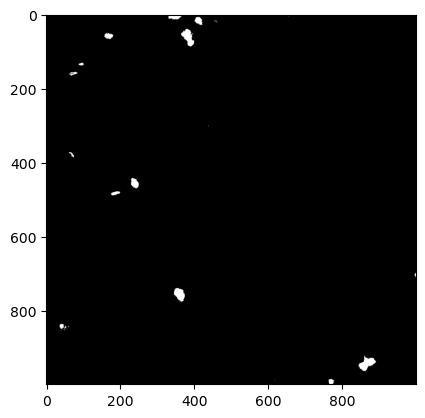

In [6]:
plt.imshow(mask, cmap='gray_r')

In [7]:
mask.min()

np.uint8(1)

In [8]:
mask.max()

np.uint8(2)

In [9]:
unique, counts = np.unique(mask, return_counts=True)
pd.Series(counts, index=unique).sort_index()

1      4908
2    995092
dtype: int64

In [1]:
binary_mask = (mask == 1).astype(np.uint8)
binary_mask

NameError: name 'mask' is not defined

In [11]:
MIN_PIXEL_AREA = 200
binary_mask = morphology.remove_small_objects(binary_mask, min_size=MIN_PIXEL_AREA).astype(np.uint8)
contours = measure.find_contours(binary_mask, 0.5)
contours

/var/folders/ry/jl4ll0zx1l709rh4r7_0cq6r0000gn/T/ipykernel_40515/3392513321.py:2: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  binary_mask = morphology.remove_small_objects(binary_mask, min_size=MIN_PIXEL_AREA).astype(np.uint8)


[array([[  0. , 329.5],
        [  0.5, 329. ],
        [  0.5, 328. ],
        [  0.5, 327. ],
        [  0. , 326.5]]),
 array([[  0. , 365.5],
        [  1. , 365.5],
        [  2. , 365.5],
        [  2.5, 366. ],
        [  3. , 366.5],
        [  4. , 366.5],
        [  4.5, 366. ],
        [  5. , 365.5],
        [  6. , 365.5],
        [  6.5, 365. ],
        [  7. , 364.5],
        [  7.5, 364. ],
        [  8. , 363.5],
        [  8.5, 363. ],
        [  8.5, 362. ],
        [  9. , 361.5],
        [  9.5, 361. ],
        [ 10. , 360.5],
        [ 10.5, 360. ],
        [ 11. , 359.5],
        [ 11.5, 359. ],
        [ 12. , 358.5],
        [ 12.5, 358. ],
        [ 13. , 357.5],
        [ 13.5, 357. ],
        [ 13.5, 356. ],
        [ 13.5, 355. ],
        [ 13. , 354.5],
        [ 12.5, 354. ],
        [ 13. , 353.5],
        [ 13.5, 353. ],
        [ 14. , 352.5],
        [ 14.5, 352. ],
        [ 14.5, 351. ],
        [ 14. , 350.5],
        [ 13. , 350.5],
        [ 12.5

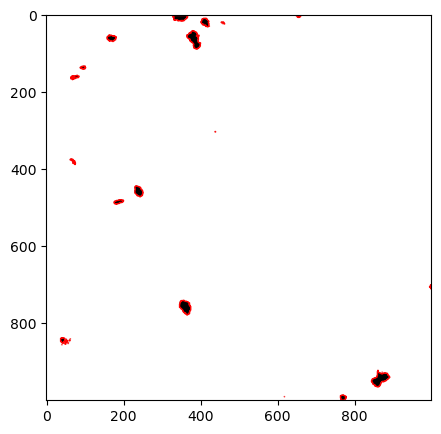

In [12]:
polygon_list = []
for contour in contours:
    contour = contour[:, [1, 0]]
    polygon = mpatches.Polygon(contour, closed=True, fill=False, edgecolor='red', linewidth=1)
    polygon_list.append(polygon)
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(binary_mask, cmap='gray_r')
for polygon in polygon_list:
    ax.add_patch(polygon)
plt.show()

In [13]:
polygon_list = []
for contour in contours:
    polygon_verts = contour[:, [1, 0]]
    polygon_list.append(Polygon(polygon_verts))

## Sanity check

In [14]:
test = polygon_list[0]
area = test.area
area

1.25

In [15]:
areas = [polygon.area for polygon in polygon_list]
areas_series = pd.Series(areas)
areas_series.describe()

count     61.000000
mean      79.803279
std      205.535571
min        0.250000
25%        0.500000
50%        0.500000
75%       18.500000
max      971.500000
dtype: float64

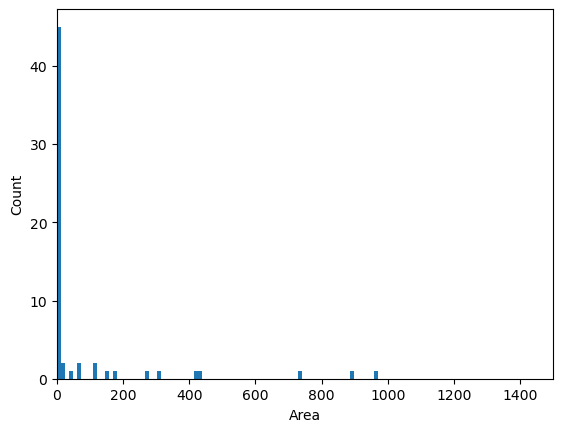

In [16]:
ax = areas_series.plot.hist(bins=80)
ax.set_xlim(0, 1500)
ax.set_xlabel('Area')
ax.set_ylabel('Count')
plt.show()

In [17]:
polygon_list_cleaned = [polygon for polygon in polygon_list if polygon.area >= 200]
polygon_list_cleaned

[<POLYGON ((365.5 0, 365.5 1, 365.5 2, 366 2.5, 366.5 3, 366.5 4, 366 4.5, 36...>,
 <POLYGON ((419 29.5, 418 29.5, 417.5 29, 417 28.5, 416 28.5, 415 28.5, 414 2...>,
 <POLYGON ((391 87.5, 390 87.5, 389.5 87, 389 86.5, 388 86.5, 387 86.5, 386.5...>,
 <POLYGON ((173 67.5, 172 67.5, 171.5 67, 171 66.5, 170 66.5, 169 66.5, 168.5...>,
 <POLYGON ((243 471.5, 242.5 471, 242 470.5, 241.5 470, 241 469.5, 240 469.5,...>,
 <POLYGON ((366 777.5, 365.5 777, 365 776.5, 364 776.5, 363.5 776, 363 775.5,...>,
 <POLYGON ((863 964.5, 862.5 964, 862 963.5, 861.5 964, 861 964.5, 860 964.5,...>]

In [18]:
df = adata.obs.copy()
cell_gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['X_centroid'], df['Y_centroid']))

cell_gdf

,Object,area,Y_centroid,X_centroid,axis_major_length,axis_minor_length,eccentricity,distance_to_bone,image_ID,disease,patient_ID,ROI,disease2,distance_to_bone_corrected,cellcharter_CN,Phenotype4,HistoneH3,disease3,geometry
Object 1 in TS-373_IMC77_B_001.csv,1,16,0.562500,801.750000,8.430760,2.420699,0.957893,26.019224,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,26.019224,ADIPOCYTES_PC,PCs,4.374106,MM,POINT (801.75 0.562)
Object 2 in TS-373_IMC77_B_001.csv,2,12,0.833333,859.583333,5.176698,2.940449,0.823017,84.005952,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,84.005952,BONE_ADIPOCYTES,Unknown,3.578988,MM,POINT (859.583 0.833)
Object 3 in TS-373_IMC77_B_001.csv,3,13,0.846154,34.000000,5.203549,3.076923,0.806443,123.405835,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,123.405835,HIF1A_IMMUNE,Neutrophils,2.832795,MM,POINT (34 0.846)
Object 4 in TS-373_IMC77_B_001.csv,4,9,1.000000,42.000000,3.265986,3.265986,0.000000,118.713942,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,118.713942,ADIPOCYTES_PC,Unknown,2.353134,MM,POINT (42 1)
Object 5 in TS-373_IMC77_B_001.csv,5,23,1.478261,57.565217,8.151264,3.901335,0.878024,110.476242,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,110.476242,PC_MYELOID,Unknown,3.813037,MM,POINT (57.565 1.478)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Object 6622 in TS-373_IMC83_B_001.csv,6622,11,998.000000,883.545455,4.077022,3.677860,0.431538,250.503493,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,250.503493,HIF1A_IMMUNE,Neutrophils,4.890736,MM,POINT (883.545 998)
Object 6623 in TS-373_IMC83_B_001.csv,6623,27,997.407407,978.703704,7.171071,5.069573,0.707266,327.273586,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,327.273586,PC_MYELOID,CD4 T,4.770726,MM,POINT (978.704 997.407)
Object 6624 in TS-373_IMC83_B_001.csv,6624,25,997.640000,996.320000,7.554137,4.235920,0.827991,342.067245,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,342.067245,BONE_MYELOID,Neutrophils,5.153814,MM,POINT (996.32 997.64)
Object 6625 in TS-373_IMC83_B_001.csv,6625,13,997.692308,820.153846,5.547002,3.412473,0.788377,195.256242,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,195.256242,PC_MYELOID,HLA-DR+ Macs/monos,4.905291,MM,POINT (820.154 997.692)


In [ ]:
all_cells_in_polygons_list = []
MIN_VECTOR_AREA = 200
MIN_PIXEL_AREA = 200

for img in cell_gdf['image_ID'].unique():
    img_name = img.replace('.csv', '.tiff')
    mask = tiff.imread(f'/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/results/MK masks/{img_name}')
    cells_in_image = cell_gdf[cell_gdf['image_ID'] == img]
    binary_mask = (mask == 1)
    binary_mask = morphology.remove_small_objects(binary_mask, min_size=MIN_PIXEL_AREA).astype(np.uint8)
    contours = measure.find_contours(binary_mask, 0.5)
    img_polygon_list = []
    for contour in contours:
        if contour.shape[0] < 4:
            continue
        polygon_verts = contour[:, [1, 0]]
        polygon = Polygon(polygon_verts)
        if polygon.area >= MIN_VECTOR_AREA:
            img_polygon_list.append({
                'geometry': polygon,
                'image_ID': img,
                'area': polygon.area
            })
    if not img_polygon_list:
        continue

    image_mask_gdf = gpd.GeoDataFrame(img_polygon_list, crs=cells_in_image.crs)
    joinged_gdf = gpd.sjoin(cells_in_image, image_mask_gdf, how='inner', predicate='within')
    all_cells_in_polygons_list.append(joinged_gdf)

In [20]:
all_cells_in_polygons = pd.concat(all_cells_in_polygons_list, ignore_index=True)
all_cells_in_polygons

,Object,area_left,Y_centroid,X_centroid,axis_major_length,axis_minor_length,eccentricity,distance_to_bone,image_ID_left,disease,...,disease2,distance_to_bone_corrected,cellcharter_CN,Phenotype4,HistoneH3,disease3,geometry,index_right,image_ID_right,area_right
0,1083,140,179.642857,912.878571,13.676246,13.268572,0.242341,160.909913,TS-373_IMC04_MGUS_002.csv,MGUS/SMM,...,MGUS,105.095195,PC_MYELOID,PCs,2.612381,MGUS,POINT (912.879 179.643),0,TS-373_IMC04_MGUS_002.csv,425.5
1,1114,49,183.306122,903.693878,9.403632,6.664060,0.705541,163.110392,TS-373_IMC04_MGUS_002.csv,MGUS/SMM,...,MGUS,106.023582,PC_MYELOID,PCs,2.430366,MGUS,POINT (903.694 183.306),0,TS-373_IMC04_MGUS_002.csv,425.5
2,1585,403,251.521092,276.667494,25.680090,20.103642,0.622211,361.809342,TS-373_IMC04_MGUS_002.csv,MGUS/SMM,...,MGUS,350.228497,PC_OXPHOS,PCs,4.020166,MGUS,POINT (276.667 251.521),1,TS-373_IMC04_MGUS_002.csv,417.5
3,5041,98,891.602041,935.979592,15.301528,8.135095,0.846963,413.353360,TS-373_IMC04_MGUS_002.csv,MGUS/SMM,...,MGUS,323.797776,ADIPOCYTES_PC,PCs,4.515921,MGUS,POINT (935.98 891.602),2,TS-373_IMC04_MGUS_002.csv,444.5
4,5063,177,897.694915,946.694915,16.290539,13.977435,0.513634,422.015403,TS-373_IMC04_MGUS_002.csv,MGUS/SMM,...,MGUS,327.835325,PC_MYELOID,PCs,4.172708,MGUS,POINT (946.695 897.695),2,TS-373_IMC04_MGUS_002.csv,444.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1212,6362,244,931.430328,863.340164,19.190926,16.901129,0.473705,194.401646,TS-373_IMC83_B_001.csv,MM_BD,...,MM_BD,194.401646,ADIPOCYTES_PC,PCs,4.658850,MM,POINT (863.34 931.43),4,TS-373_IMC83_B_001.csv,971.5
1213,6366,87,931.827586,878.908046,11.323385,9.858652,0.491911,208.021633,TS-373_IMC83_B_001.csv,MM_BD,...,MM_BD,208.021633,PC_MYELOID,PCs,3.934625,MM,POINT (878.908 931.828),4,TS-373_IMC83_B_001.csv,971.5
1214,6383,49,938.795918,882.755102,9.057903,6.945989,0.641835,215.295146,TS-373_IMC83_B_001.csv,MM_BD,...,MM_BD,215.295146,ADIPOCYTES_PC,PCs,3.258133,MM,POINT (882.755 938.796),4,TS-373_IMC83_B_001.csv,971.5
1215,6391,146,941.041096,872.383562,14.579974,13.026932,0.449101,207.460840,TS-373_IMC83_B_001.csv,MM_BD,...,MM_BD,207.460840,ADIPOCYTES_PC,PCs,4.495313,MM,POINT (872.384 941.041),4,TS-373_IMC83_B_001.csv,971.5


In [39]:
all_cells_in_polygons['image_ID_left'].value_counts()

image_ID_left
TS-373_IMC43_B_002.csv       94
TS-373_IMC72_MGUS_002.csv    84
TS-373_IMC15_B_002.csv       72
TS-373_IMC48_B_001.csv       37
TS-373_IMC72_MGUS_001.csv    37
                             ..
TS-373_IMC25_B_002.csv        0
TS-373_IMC75-1_B_002.csv      0
TS-373_IMC77_B_001.csv        0
TS-373_IMC25_B_001.csv        0
TS-373_IMC77_B_002.csv        0
Name: count, Length: 152, dtype: int64

In [21]:
subset_keys = all_cells_in_polygons[['Object', 'image_ID_left']].copy()
subset_keys['inside_polygon'] = True
subset_keys.rename(columns={'image_ID_left': 'image_ID'}, inplace=True)

In [22]:
df = pd.merge(adata.to_df(),adata.obs, left_index=True, right_index=True)
df

,CD38,Perilipin,Vimentin,B4GALT1,MPO,CathepsinK,ATP5A,RUNX2,HIF1A,CD11b,...,image_ID,disease,patient_ID,ROI,disease2,distance_to_bone_corrected,cellcharter_CN,Phenotype4,HistoneH3,disease3
Object 1 in TS-373_IMC77_B_001.csv,0.285836,0.294962,0.381280,0.208380,0.470309,0.000000,0.347032,0.118177,0.245371,0.422768,...,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,26.019224,ADIPOCYTES_PC,PCs,4.374106,MM
Object 2 in TS-373_IMC77_B_001.csv,0.437678,0.425806,0.730220,0.539852,0.814078,0.153551,0.202306,0.000000,0.670883,0.632502,...,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,84.005952,BONE_ADIPOCYTES,Unknown,3.578988,MM
Object 3 in TS-373_IMC77_B_001.csv,0.187705,0.185489,1.009269,0.506163,0.770498,0.041015,0.347042,0.075689,0.889004,0.901242,...,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,123.405835,HIF1A_IMMUNE,Neutrophils,2.832795,MM
Object 4 in TS-373_IMC77_B_001.csv,0.367975,0.144265,0.593424,0.173114,0.517508,0.062037,0.253639,0.199798,0.712216,0.430238,...,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,118.713942,ADIPOCYTES_PC,Unknown,2.353134,MM
Object 5 in TS-373_IMC77_B_001.csv,0.544195,0.216297,0.881555,0.338833,0.487923,0.049646,0.195340,0.000000,0.475726,0.511521,...,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,110.476242,PC_MYELOID,Unknown,3.813037,MM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Object 6622 in TS-373_IMC83_B_001.csv,0.630851,0.510358,0.851935,0.611909,0.717809,0.386979,0.513777,0.287785,1.042704,0.817466,...,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,250.503493,HIF1A_IMMUNE,Neutrophils,4.890736,MM
Object 6623 in TS-373_IMC83_B_001.csv,0.709539,0.382684,0.763277,0.516783,0.650090,0.341883,0.793174,0.214325,0.922652,0.636815,...,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,327.273586,PC_MYELOID,CD4 T,4.770726,MM
Object 6624 in TS-373_IMC83_B_001.csv,0.702654,0.439202,0.623626,0.600737,0.834559,0.405722,0.725622,0.256038,0.877806,0.622458,...,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,342.067245,BONE_MYELOID,Neutrophils,5.153814,MM
Object 6625 in TS-373_IMC83_B_001.csv,0.612524,0.427313,0.749995,0.585002,0.678468,0.399090,0.715312,0.193437,0.902942,0.605583,...,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,195.256242,PC_MYELOID,HLA-DR+ Macs/monos,4.905291,MM


In [23]:
master_df = df.merge(subset_keys, on=['Object', 'image_ID'], how='left')
master_df['inside_polygon'] = master_df['inside_polygon'].fillna(False)

/var/folders/ry/jl4ll0zx1l709rh4r7_0cq6r0000gn/T/ipykernel_40515/3957773220.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  master_df['inside_polygon'] = master_df['inside_polygon'].fillna(False)


In [24]:
master_df[master_df['inside_polygon'] == True]

,CD38,Perilipin,Vimentin,B4GALT1,MPO,CathepsinK,ATP5A,RUNX2,HIF1A,CD11b,...,disease,patient_ID,ROI,disease2,distance_to_bone_corrected,cellcharter_CN,Phenotype4,HistoneH3,disease3,inside_polygon
14278,0.373946,0.303737,0.428628,0.628021,0.312804,0.097765,0.429500,0.070384,0.881305,0.681004,...,MGUS/SMM,IMC04,002,MGUS,105.095195,PC_MYELOID,PCs,2.612381,MGUS,True
14309,0.357163,0.260173,0.068916,0.800469,0.130770,0.024487,0.404141,0.083676,0.558961,0.569915,...,MGUS/SMM,IMC04,002,MGUS,106.023582,PC_MYELOID,PCs,2.430366,MGUS,True
14780,0.559047,0.286907,0.557045,0.636835,0.283836,0.094119,0.518236,0.073344,0.754331,0.630709,...,MGUS/SMM,IMC04,002,MGUS,350.228497,PC_OXPHOS,PCs,4.020166,MGUS,True
18233,0.522330,0.424060,0.670683,0.600078,0.237931,0.156910,0.743531,0.080476,0.404327,0.611859,...,MGUS/SMM,IMC04,002,MGUS,323.797776,ADIPOCYTES_PC,PCs,4.515921,MGUS,True
18255,0.434809,0.322390,0.385175,0.620369,0.196423,0.091610,0.657263,0.059875,0.294211,0.558941,...,MGUS/SMM,IMC04,002,MGUS,327.835325,PC_MYELOID,PCs,4.172708,MGUS,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1006862,0.618201,0.284679,0.302486,0.669776,0.302146,0.120038,0.626195,0.101479,0.736761,0.556509,...,MM_BD,IMC83,001,MM_BD,194.401646,ADIPOCYTES_PC,PCs,4.658850,MM,True
1006866,0.639665,0.294883,0.254425,0.700123,0.252164,0.168280,0.830178,0.118375,0.590505,0.588229,...,MM_BD,IMC83,001,MM_BD,208.021633,PC_MYELOID,PCs,3.934625,MM,True
1006883,0.633111,0.326218,0.215086,0.771875,0.154549,0.110524,0.847493,0.126878,0.559553,0.591703,...,MM_BD,IMC83,001,MM_BD,215.295146,ADIPOCYTES_PC,PCs,3.258133,MM,True
1006891,0.604866,0.279274,0.191508,0.740157,0.172616,0.147143,0.783771,0.130209,0.549262,0.561833,...,MM_BD,IMC83,001,MM_BD,207.460840,ADIPOCYTES_PC,PCs,4.495313,MM,True


In [25]:
print(master_df)

             CD38  Perilipin  Vimentin   B4GALT1       MPO  CathepsinK  \
0        0.285836   0.294962  0.381280  0.208380  0.470309    0.000000   
1        0.437678   0.425806  0.730220  0.539852  0.814078    0.153551   
2        0.187705   0.185489  1.009269  0.506163  0.770498    0.041015   
3        0.367975   0.144265  0.593424  0.173114  0.517508    0.062037   
4        0.544195   0.216297  0.881555  0.338833  0.487923    0.049646   
...           ...        ...       ...       ...       ...         ...   
1007122  0.630851   0.510358  0.851935  0.611909  0.717809    0.386979   
1007123  0.709539   0.382684  0.763277  0.516783  0.650090    0.341883   
1007124  0.702654   0.439202  0.623626  0.600737  0.834559    0.405722   
1007125  0.612524   0.427313  0.749995  0.585002  0.678468    0.399090   
1007126  0.658025   0.362593  0.802902  0.623439  0.631292    0.341972   

            ATP5A     RUNX2     HIF1A     CD11b  ...  disease  patient_ID  \
0        0.347032  0.118177  0.245

In [26]:
master_df[master_df['inside_polygon'] == True]['image_ID'].nunique()

107

Rate of mk-related missclassification across all cells, acorss images, across phenotypes per image
Analyze PC-CD138/IRF expression inside MKs compare to 'correct' PCs

In [27]:
# safer f-string quoting and use boolean mean for the proportion
print(f"The proportion of missclassified cells due to MKs is {master_df['inside_polygon'].mean():.6f}")

The proportion of missclassified cells due to MKs is 0.001208


In [28]:
pcs = master_df[master_df['Phenotype4'] == 'PCs']
print(f'The proportion of PCs missclassified due to MKs is {pcs["inside_polygon"].mean():.6f}')

The proportion of PCs missclassified due to MKs is 0.003039


In [29]:
rates_df = master_df.groupby(['image_ID'])['inside_polygon'] \
                 .mean() \
                 .reset_index(name='rate_misclassified')
rates_df

/var/folders/ry/jl4ll0zx1l709rh4r7_0cq6r0000gn/T/ipykernel_40515/714405522.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rates_df = master_df.groupby(['image_ID'])['inside_polygon'] \


,image_ID,rate_misclassified
0,TS-373_IMC01_UB_001.csv,0.000472
1,TS-373_IMC01_UB_002.csv,0.000000
2,TS-373_IMC02_MGUS_001.csv,0.002192
3,TS-373_IMC02_MGUS_002.csv,0.000000
4,TS-373_IMC03_MGUS_001.csv,0.000000
...,...,...
147,TS-373_IMC93_B_002.csv,0.000670
148,TS-373_IMC95_B_001.csv,0.000000
149,TS-373_IMC95_B_002.csv,0.000375
150,TS-373_IMC96_B_001.csv,0.000809


In [30]:
disease_map = master_df[['disease3', 'image_ID']].drop_duplicates()
disease_map = disease_map.set_index('image_ID')

In [31]:
rates_df['disease'] = rates_df['image_ID'].map(disease_map['disease3'])
rates_df['rate_misclassified'] *= 100
rates_df

,image_ID,rate_misclassified,disease
0,TS-373_IMC01_UB_001.csv,0.047237,MM
1,TS-373_IMC01_UB_002.csv,0.000000,MM
2,TS-373_IMC02_MGUS_001.csv,0.219230,MGUS
3,TS-373_IMC02_MGUS_002.csv,0.000000,MGUS
4,TS-373_IMC03_MGUS_001.csv,0.000000,MGUS
...,...,...,...
147,TS-373_IMC93_B_002.csv,0.067047,MM
148,TS-373_IMC95_B_001.csv,0.000000,MM
149,TS-373_IMC95_B_002.csv,0.037472,MM
150,TS-373_IMC96_B_001.csv,0.080925,MM


/var/folders/ry/jl4ll0zx1l709rh4r7_0cq6r0000gn/T/ipykernel_40515/1264691479.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rates_df, x='disease', y='rate_misclassified', palette=disease3_color_map, showcaps=False, linewidth=2, width=0.75)


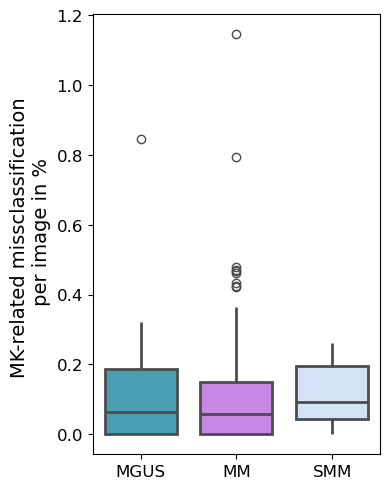

In [32]:
fig, ax = plt.subplots(figsize=(4, 5))
sns.boxplot(data=rates_df, x='disease', y='rate_misclassified', palette=disease3_color_map, showcaps=False, linewidth=2, width=0.75)
plt.xlabel('')
plt.ylabel('MK-related missclassification \n per image in %', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(save_path, f'MK_misclassification_rate_per_image.{extension}'))

In [33]:
master_df

,CD38,Perilipin,Vimentin,B4GALT1,MPO,CathepsinK,ATP5A,RUNX2,HIF1A,CD11b,...,disease,patient_ID,ROI,disease2,distance_to_bone_corrected,cellcharter_CN,Phenotype4,HistoneH3,disease3,inside_polygon
0,0.285836,0.294962,0.381280,0.208380,0.470309,0.000000,0.347032,0.118177,0.245371,0.422768,...,MM_BD,IMC77,001,MM_BD,26.019224,ADIPOCYTES_PC,PCs,4.374106,MM,False
1,0.437678,0.425806,0.730220,0.539852,0.814078,0.153551,0.202306,0.000000,0.670883,0.632502,...,MM_BD,IMC77,001,MM_BD,84.005952,BONE_ADIPOCYTES,Unknown,3.578988,MM,False
2,0.187705,0.185489,1.009269,0.506163,0.770498,0.041015,0.347042,0.075689,0.889004,0.901242,...,MM_BD,IMC77,001,MM_BD,123.405835,HIF1A_IMMUNE,Neutrophils,2.832795,MM,False
3,0.367975,0.144265,0.593424,0.173114,0.517508,0.062037,0.253639,0.199798,0.712216,0.430238,...,MM_BD,IMC77,001,MM_BD,118.713942,ADIPOCYTES_PC,Unknown,2.353134,MM,False
4,0.544195,0.216297,0.881555,0.338833,0.487923,0.049646,0.195340,0.000000,0.475726,0.511521,...,MM_BD,IMC77,001,MM_BD,110.476242,PC_MYELOID,Unknown,3.813037,MM,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1007122,0.630851,0.510358,0.851935,0.611909,0.717809,0.386979,0.513777,0.287785,1.042704,0.817466,...,MM_BD,IMC83,001,MM_BD,250.503493,HIF1A_IMMUNE,Neutrophils,4.890736,MM,False
1007123,0.709539,0.382684,0.763277,0.516783,0.650090,0.341883,0.793174,0.214325,0.922652,0.636815,...,MM_BD,IMC83,001,MM_BD,327.273586,PC_MYELOID,CD4 T,4.770726,MM,False
1007124,0.702654,0.439202,0.623626,0.600737,0.834559,0.405722,0.725622,0.256038,0.877806,0.622458,...,MM_BD,IMC83,001,MM_BD,342.067245,BONE_MYELOID,Neutrophils,5.153814,MM,False
1007125,0.612524,0.427313,0.749995,0.585002,0.678468,0.399090,0.715312,0.193437,0.902942,0.605583,...,MM_BD,IMC83,001,MM_BD,195.256242,PC_MYELOID,HLA-DR+ Macs/monos,4.905291,MM,False


In [34]:
master_df.groupby(['image_ID', 'Phenotype4'])['inside_polygon'].mean()

/var/folders/ry/jl4ll0zx1l709rh4r7_0cq6r0000gn/T/ipykernel_40515/1579693656.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  master_df.groupby(['image_ID', 'Phenotype4'])['inside_polygon'].mean()


image_ID                 Phenotype4 
TS-373_IMC01_UB_001.csv  Adipocytes     0.000000
                         CD4 T          0.000000
                         CD8 T          0.000000
                         DCs            0.000000
                         Endothelial    0.000000
                                          ...   
TS-373_IMC96_B_002.csv   OB/RUNX2+      0.000000
                         Osteoclasts    0.000000
                         Osteocytes          NaN
                         PCs            0.001681
                         Unknown        0.000000
Name: inside_polygon, Length: 2280, dtype: float64

In [35]:
rates_df = master_df.groupby(['image_ID', 'Phenotype4'])['inside_polygon'] \
                         .mean() \
                         .reset_index(name='misclassification_rate')
rates_df['misclassification_rate'] *= 100

/var/folders/ry/jl4ll0zx1l709rh4r7_0cq6r0000gn/T/ipykernel_40515/652096656.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rates_df = master_df.groupby(['image_ID', 'Phenotype4'])['inside_polygon'] \


In [36]:
rates_df

,image_ID,Phenotype4,misclassification_rate
0,TS-373_IMC01_UB_001.csv,Adipocytes,0.000000
1,TS-373_IMC01_UB_001.csv,CD4 T,0.000000
2,TS-373_IMC01_UB_001.csv,CD8 T,0.000000
3,TS-373_IMC01_UB_001.csv,DCs,0.000000
4,TS-373_IMC01_UB_001.csv,Endothelial,0.000000
...,...,...,...
2275,TS-373_IMC96_B_002.csv,OB/RUNX2+,0.000000
2276,TS-373_IMC96_B_002.csv,Osteoclasts,0.000000
2277,TS-373_IMC96_B_002.csv,Osteocytes,NaN
2278,TS-373_IMC96_B_002.csv,PCs,0.168067


/var/folders/ry/jl4ll0zx1l709rh4r7_0cq6r0000gn/T/ipykernel_40515/3957723705.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rates_df, x='Phenotype4', y='misclassification_rate', palette=phenotype_color_map, linewidth=2, width=0.75, capsize=0.25, edgecolor='black', errcolor='black')
/var/folders/ry/jl4ll0zx1l709rh4r7_0cq6r0000gn/T/ipykernel_40515/3957723705.py:2: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'black'}` instead.

  sns.barplot(data=rates_df, x='Phenotype4', y='misclassification_rate', palette=phenotype_color_map, linewidth=2, width=0.75, capsize=0.25, edgecolor='black', errcolor='black')


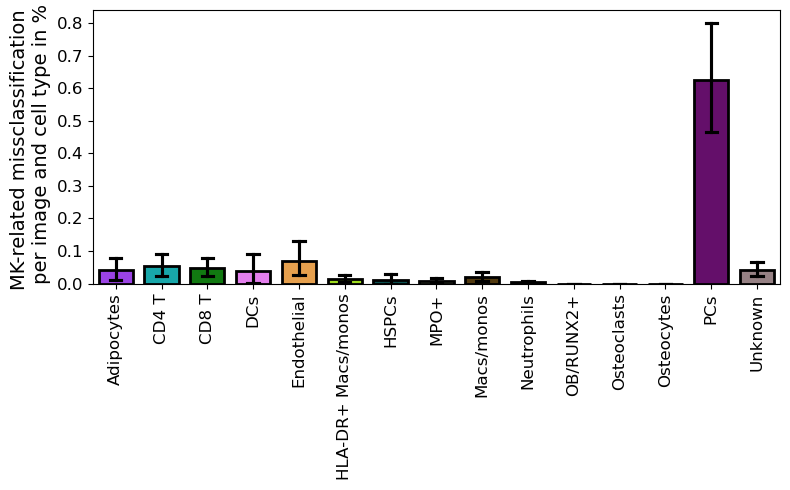

In [37]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=rates_df, x='Phenotype4', y='misclassification_rate', palette=phenotype_color_map, linewidth=2, width=0.75, capsize=0.25, edgecolor='black', errcolor='black')
plt.xlabel('')
plt.ylabel(f'MK-related missclassification \n per image and cell type in %', fontsize=14)
plt.xticks(fontsize=12, rotation=90)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(save_path, f'MK_misclassification_rate_per_image_per_celltype.{extension}'))